# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberta a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">

<b>Comentário geral: </b> <a class="tocSkip"></a>

Parabéns pela conclusão do projeto, Raphael! 🎉

Estou muito feliz com o seu empenho e dedicação! O projeto foi muito bom e estou contente em dizer que está aprovado! 

Bora para os próximos desafios!🚀
</div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
import numpy as np



In [2]:

df = pd.read_csv('/datasets/logs_exp_us.csv', sep ='\t')

df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- O conjunto de dados foi carregado corretamente
- O import das bibliotecas foi feito de forma correta e em uma célula separada
</div>

In [3]:
df = df.rename(columns={
    "EventName": "event_name",
    "DeviceIDHash": "user_id",
    "EventTimestamp": "event_timestamp",
    "ExpId": "exp_id"
})

In [4]:
df['event_name'].isna().sum()

0

In [5]:
df["user_id"].isna().sum()

0

In [6]:
df["event_timestamp"].isna().sum()

0

In [7]:
df["exp_id"].isna().sum()

0

In [8]:
df.describe()

,user_id,event_timestamp,exp_id
count,2.441260e+05,2.441260e+05,244126.000000
mean,4.627568e+18,1.564914e+09,247.022296
std,2.642425e+18,1.771343e+05,0.824434
min,6.888747e+15,1.564030e+09,246.000000
25%,2.372212e+18,1.564757e+09,246.000000
50%,4.623192e+18,1.564919e+09,247.000000
75%,6.932517e+18,1.565075e+09,248.000000
max,9.222603e+18,1.565213e+09,248.000000


In [9]:
df['event_name'].unique()

array(['MainScreenAppear', 'PaymentScreenSuccessful', 'CartScreenAppear',
       'OffersScreenAppear', 'Tutorial'], dtype=object)

In [10]:
df['user_id'].nunique()

7551

In [11]:
df['user_id'].head(10)

0    4575588528974610257
1    7416695313311560658
2    3518123091307005509
3    3518123091307005509
4    6217807653094995999
5    6217807653094995999
6    8351860793733343758
7    5682100281902512875
8    1850981295691852772
9    5407636962369102641
Name: user_id, dtype: int64

In [12]:
df.groupby('exp_id')['user_id'].nunique()

exp_id
246    2489
247    2520
248    2542
Name: user_id, dtype: int64

In [13]:
df['user_id'].value_counts()

6304868067479728361    2308
197027893265565660     2003
4623191541214045580    1771
6932517045703054087    1448
1754140665440434215    1222
                       ... 
8188293597840107588       1
1616856457908967248       1
732356052255400077        1
6671109879025379318       1
2275878174127603404       1
Name: user_id, Length: 7551, dtype: int64

In [14]:
import datetime
print(datetime.datetime.fromtimestamp(1564029816))

2019-07-25 04:43:36


In [15]:
df["event_timestamp"] = pd.to_datetime(df["event_timestamp"], unit='s')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_name       244126 non-null  object        
 1   user_id          244126 non-null  int64         
 2   event_timestamp  244126 non-null  datetime64[ns]
 3   exp_id           244126 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 7.5+ MB


In [17]:
print(df['event_timestamp'])

0        2019-07-25 04:43:36
1        2019-07-25 11:11:42
2        2019-07-25 11:28:47
3        2019-07-25 11:28:47
4        2019-07-25 11:48:42
                 ...        
244121   2019-08-07 21:12:25
244122   2019-08-07 21:13:59
244123   2019-08-07 21:14:43
244124   2019-08-07 21:14:58
244125   2019-08-07 21:15:17
Name: event_timestamp, Length: 244126, dtype: datetime64[ns]


In [18]:
df["event_timestamp"].head(20)

0    2019-07-25 04:43:36
1    2019-07-25 11:11:42
2    2019-07-25 11:28:47
3    2019-07-25 11:28:47
4    2019-07-25 11:48:42
5    2019-07-25 11:48:43
6    2019-07-25 14:50:42
7    2019-07-25 20:14:37
8    2019-07-25 20:31:42
9    2019-07-26 03:35:12
10   2019-07-26 05:33:34
11   2019-07-26 06:50:26
12   2019-07-26 06:54:45
13   2019-07-26 07:22:12
14   2019-07-26 10:06:00
15   2019-07-26 11:31:08
16   2019-07-26 11:43:41
17   2019-07-26 12:31:23
18   2019-07-26 13:49:05
19   2019-07-26 14:04:26
Name: event_timestamp, dtype: datetime64[ns]

In [19]:
df['event_date'] = df["event_timestamp"].dt.date
print(df['event_date'])

0         2019-07-25
1         2019-07-25
2         2019-07-25
3         2019-07-25
4         2019-07-25
             ...    
244121    2019-08-07
244122    2019-08-07
244123    2019-08-07
244124    2019-08-07
244125    2019-08-07
Name: event_date, Length: 244126, dtype: object


In [20]:
df.shape

(244126, 5)

In [21]:
 df["event_name"].value_counts()


MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: event_name, dtype: int64

In [22]:
df_ordenado = df.sort_values(by=['user_id', 'event_timestamp'])
df_ordenado.groupby('event_name')['user_id'].nunique()

event_name
CartScreenAppear           3749
MainScreenAppear           7439
OffersScreenAppear         4613
PaymentScreenSuccessful    3547
Tutorial                    847
Name: user_id, dtype: int64

In [23]:

total_events = df.shape[0]

total_user = df['user_id'].nunique()

user_media = total_events / total_user

print('O numero medio de eventos por usuarios é:', user_media)


O numero medio de eventos por usuarios é: 32.33028737915508


In [24]:
df.columns

Index(['event_name', 'user_id', 'event_timestamp', 'exp_id', 'event_date'], dtype='object')

In [25]:
df['event_timestamp'].min()


Timestamp('2019-07-25 04:43:36')

In [26]:

df['event_timestamp'].max()

Timestamp('2019-08-07 21:15:17')

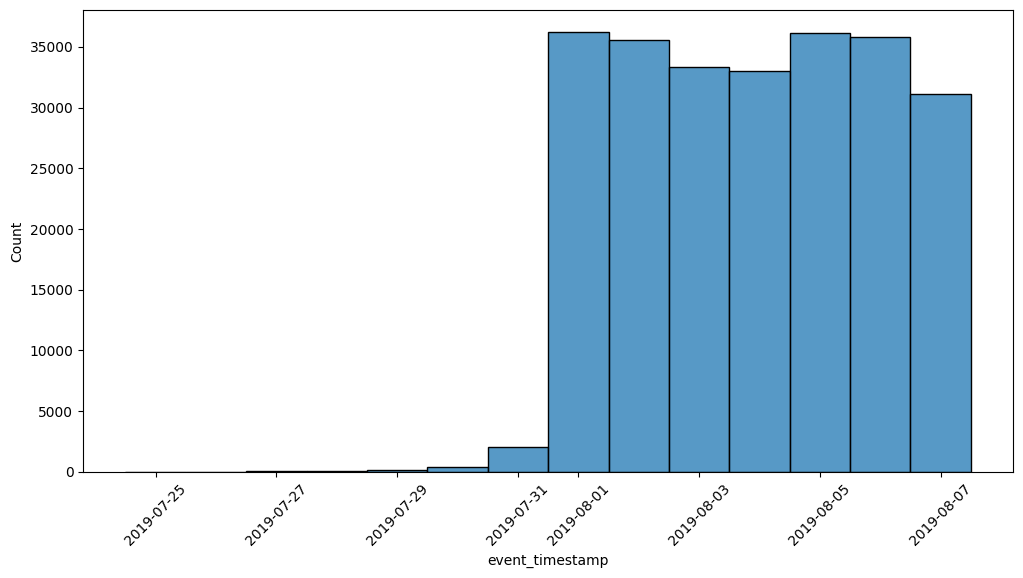

In [27]:
plt.figure(figsize=(12,6))
sns.histplot(x=df['event_timestamp'].dt.date)
plt.xticks(rotation=45)
plt.show()  

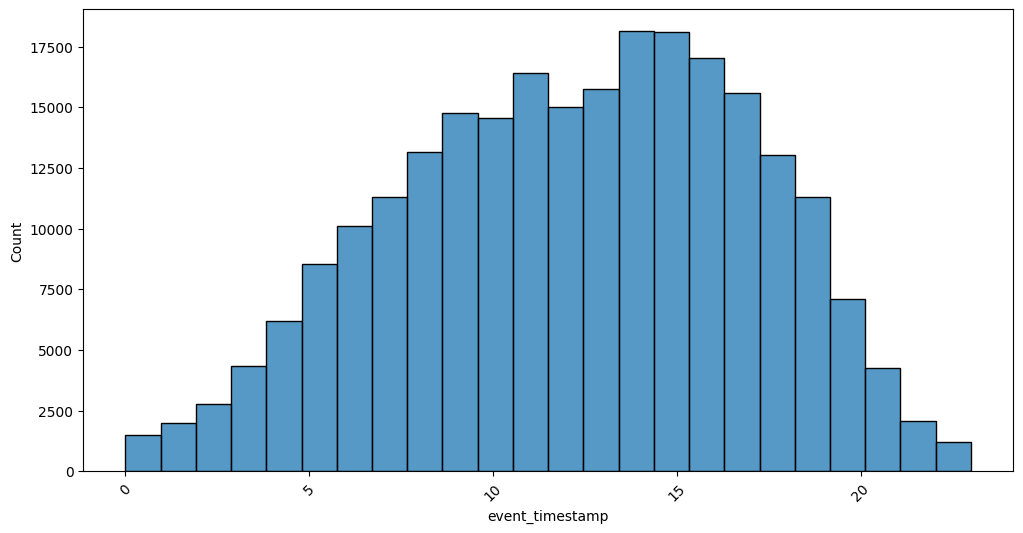

In [28]:
plt.figure(figsize=(12,6))
sns.histplot(x=df['event_timestamp'].dt.hour, bins=24)
plt.xticks(rotation=45)
plt.show()  

In [29]:
eventos_por_data = df['event_date'].value_counts().sort_index()
print(eventos_por_data)

2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      413
2019-07-31     2031
2019-08-01    36229
2019-08-02    35606
2019-08-03    33351
2019-08-04    33033
2019-08-05    36113
2019-08-06    35822
2019-08-07    31144
Name: event_date, dtype: int64


“Ao analisar o número de eventos por dia, observamos que o período de 25/07/2019 a 30/07/2019 apresenta um volume extremamente baixo de registros, indicando dados incompletos. A partir de 31/07/2019, o volume de eventos aumenta de forma abrupta e se mantém estável até 07/08/2019. Portanto, consideramos que os dados estão completos apenas a partir de 31/07/2019, e esse será o período utilizado para a análise.”

In [30]:

df['event_date'] = pd.to_datetime(df['event_date'])
df = df[df['event_date'] >= '2019-07-31']
print(df['event_date'])

797      2019-07-31
798      2019-07-31
799      2019-07-31
800      2019-07-31
801      2019-07-31
            ...    
244121   2019-08-07
244122   2019-08-07
244123   2019-08-07
244124   2019-08-07
244125   2019-08-07
Name: event_date, Length: 243329, dtype: datetime64[ns]


<div class="alert alert-block alert-success">
<b>Comentário do revisor:</b> <a class="tocSkip"></a>

- A distribuição dos eventos foi realizada corretamente, boa análise! 👏  
- Foi realizado o filtro temporal

In [31]:
print(f"Data mínima após filtro: {df['event_timestamp'].min()}")
print(f"Data máxima após filtro: {df['event_timestamp'].max()}")
print(f"Período analisado: {(df['event_timestamp'].max() - df['event_timestamp'].min()).days + 1} dias")

Data mínima após filtro: 2019-07-31 01:11:46
Data máxima após filtro: 2019-08-07 21:15:17
Período analisado: 8 dias


In [32]:
eventos_perdidos = 244126 - 243329
usuarios_antes = 7551  # Você precisa calcular quantos usuários únicos havia antes do filtro
usuarios_depois = df['user_id'].nunique()
usuarios_perdidos = usuarios_antes - usuarios_depois

print(f"Eventos perdidos: {eventos_perdidos}")
print(f"Usuários perdidos: {usuarios_perdidos}")
print(f"% de eventos perdidos: {(eventos_perdidos/244126)*100:.2f}%")
print(f"% de usuários perdidos: {(usuarios_perdidos/usuarios_antes)*100:.2f}%")

Eventos perdidos: 797
Usuários perdidos: 9
% de eventos perdidos: 0.33%
% de usuários perdidos: 0.12%


In [33]:
print("Usuários por grupo experimental após filtro:")
print(df.groupby('exp_id')['user_id'].nunique())

Usuários por grupo experimental após filtro:
exp_id
246    2485
247    2517
248    2540
Name: user_id, dtype: int64


In [34]:
freq_events = df['event_name'].value_counts().sort_values(ascending=False)
print('Ordem de frequencia dos eventos:')
print(freq_events)

Ordem de frequencia dos eventos:
MainScreenAppear           118681
OffersScreenAppear          46724
CartScreenAppear            42623
PaymentScreenSuccessful     34253
Tutorial                     1048
Name: event_name, dtype: int64


A análise da frequência dos eventos mostra que MainScreenAppear é o evento mais comum, seguido por OffersScreenAppear, CartScreenAppear e PaymentScreenSuccessful. A maior queda ocorre logo no início do funil: muitos usuários abrem o aplicativo, mas não avançam para visualizar ofertas, o que pode indicar abandono precoce ou dificuldades na navegação inicial. Entre OffersScreenAppear e CartScreenAppear a redução é pequena, sugerindo boa transição para o carrinho. Já entre CartScreenAppear e PaymentScreenSuccessful a queda volta a ser relevante, refletindo abandono de carrinho, algo típico em processos de compra digital.


In [35]:
user_events = df.groupby('event_name')['user_id'].nunique().sort_values(ascending=False)

prop_offers = user_events['OffersScreenAppear'] / user_events['MainScreenAppear']
prop_cart = user_events['CartScreenAppear'] / user_events['OffersScreenAppear']
prop_pay = user_events['PaymentScreenSuccessful'] / user_events['CartScreenAppear']

prop_offers, prop_cart, prop_pay

(0.6200026921523758, 0.8124185844550587, 0.9465526456440406)

In [36]:

percent_offers = user_events['OffersScreenAppear'] / user_events['MainScreenAppear'] * 100
percent_cart = user_events['CartScreenAppear'] / user_events['OffersScreenAppear'] * 100
percent_pay = user_events['PaymentScreenSuccessful'] / user_events['CartScreenAppear'] * 100


percent_offers, percent_cart, percent_pay

(62.00026921523758, 81.24185844550587, 94.65526456440406)

Análise das taxas de conversão do funil

62% dos usuários únicos que acederam ao aplicativo avançaram para a tela de ofertas.
Isso representa uma queda de 38% logo no início do funil, indicando que muitos usuários entram no app mas não continuam para explorar as ofertas. Esse comportamento pode refletir abandono precoce ou dificuldades na navegação inicial, entre outros fatores possíveis.

81,24% dos usuários que visualizam as ofertas seguem para a tela do carrinho.
Essa é uma taxa de conversão elevada, sugerindo que a maioria dos usuários que chega a ver produtos demonstra intenção de compra.

94,65% dos usuários que chegam ao carrinho avançam para a tela de pagamento concluído.
Essa é uma taxa de conversão excelente, indicando que quase todos os usuários que adicionam itens ao carrinho finalizam a compra.

In [39]:
funil_ordem = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']
conversao_completa = user_events['PaymentScreenSuccessful'] / user_events['MainScreenAppear']
conversao_porcentagem = user_events['PaymentScreenSuccessful'] / user_events['MainScreenAppear'] * 100
conversao_completa, conversao_porcentagem

(0.47678018575851394, 47.6780185758514)

47% dos usuários completam o funil. Esse valor é fortemente impactado pela queda de 38% entre a tela inicial e a tela de ofertas. Embora as etapas seguintes apresentem taxas de conversão elevadas, a perda inicial sugere que a tela principal pode precisar de ajustes de navegação, clareza ou layout para reduzir o abandono precoce.


In [40]:
users_per_group = df.groupby('exp_id')['user_id'].nunique()
print(users_per_group)


exp_id
246    2485
247    2517
248    2540
Name: user_id, dtype: int64


In [43]:
from scipy import stats

events = df['event_name'].unique()

for event in events:
    # usuários que fizeram o evento em cada grupo
    users_event = df[df['event_name'] == event].groupby('exp_id')['user_id'].nunique()
    
    # usuários totais por grupo
    users_total = df.groupby('exp_id')['user_id'].nunique()
    
    # grupo 246
    a = users_event.get(246, 0)              # fizeram o evento
    b = users_total[246] - a                 # não fizeram
    
    # grupo 247
    c = users_event.get(247, 0)
    d = users_total[247] - c
    
    # tabela 2x2
    table = [[a, b],
             [c, d]]
    
    chi2, p, dof, expected = stats.chi2_contingency(table)
    
    print(event, "p-valor =", p)

MainScreenAppear p-valor = 0.6716866985184053
OffersScreenAppear p-valor = 0.28730258973807377
Tutorial p-valor = 0.9145554906726088
PaymentScreenSuccessful p-valor = 0.1186506764402031
CartScreenAppear p-valor = 0.22363755471576394


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- A proporção de usuários por etapa do funil foi analisada
- A ordem das etapas foi calculada
- A conversão dos usuários por etapa do funil foi analisada
- O percentual de usuários que percorrem todo o caminho foi calculado
- O número de usuários por grupo foi analisado
</div>


Os grupos 246 e 247 não apresentaram diferenças estatisticamente significativas em nenhum dos eventos analisados. Isso confirma que a divisão dos grupos de controle foi realizada corretamente e que o experimento está calibrado.

In [46]:
users_event = df[df['event_name'] == 'MainScreenAppear'].groupby('exp_id')['user_id'].nunique()
users_total = df.groupby('exp_id')['user_id'].nunique()

a = users_event.get(246, 0)
b = users_total[246] - a

c = users_event.get(247, 0)
d = users_total[247] - c

table = [[a, b],
         [c, d]]

chi2, p, dof, expected = stats.chi2_contingency(table)
print(p)

events = df['event_name'].unique()


for event in events:
    users_event = df[df['event_name'] == event].groupby('exp_id')['user_id'].nunique()
    users_total = df.groupby('exp_id')['user_id'].nunique()

    a = users_event.get(246, 0)
    b = users_total[246] - a
    c = users_event.get(247, 0)
    d = users_total[247] - c
    
    # Calcular proporções
    prop_246 = a / users_total[246]
    prop_247 = c / users_total[247]

    table = [[a, b], [c, d]]
    chi2, p, dof, expected = stats.chi2_contingency(table)
    
    print(f"{event}: Prop_246={prop_246:.3f}, Prop_247={prop_247:.3f}, p-valor={p:.3f}")


0.6716866985184053
MainScreenAppear: Prop_246=0.987, Prop_247=0.985, p-valor=0.672
OffersScreenAppear: Prop_246=0.621, Prop_247=0.606, p-valor=0.287
Tutorial: Prop_246=0.112, Prop_247=0.113, p-valor=0.915
PaymentScreenSuccessful: Prop_246=0.483, Prop_247=0.460, p-valor=0.119
CartScreenAppear: Prop_246=0.510, Prop_247=0.492, p-valor=0.224


Conclusão:
Os grupos 246 e 247 são estatisticamente idênticos.
O teste A/A passou — a divisão dos grupos está correta.


In [47]:
events = df['event_name'].unique()
users_total = df.groupby('exp_id')['user_id'].nunique()

for event in events:
    users_event = df[df['event_name'] == event].groupby('exp_id')['user_id'].nunique()

    a = users_event.get(248, 0)
    b = users_total[248] - a

    c = users_event.get(246, 0)
    d = users_total[246] - c

    table = [[a, b],
             [c, d]]

    chi2, p, dof, expected = stats.chi2_contingency(table)
    print(event, "p-valor 248 vs 246 =", p)


MainScreenAppear p-valor 248 vs 246 = 0.40356114905832097
OffersScreenAppear p-valor 248 vs 246 = 0.23833161374723072
Tutorial p-valor 248 vs 246 = 0.9596193186979824
PaymentScreenSuccessful p-valor 248 vs 246 = 0.23445453773299513
CartScreenAppear p-valor 248 vs 246 = 0.1053462139866914


Conclusão:
O grupo 248 não difere do grupo 246 em nenhum evento.


In [48]:
for event in events:
    users_event = df[df['event_name'] == event].groupby('exp_id')['user_id'].nunique()

    a = users_event.get(248, 0)
    b = users_total[248] - a

    c = users_event.get(247, 0)
    d = users_total[247] - c

    table = [[a, b],
             [c, d]]

    chi2, p, dof, expected = stats.chi2_contingency(table)
    print(event, "p-valor 248 vs 247 =", p)


MainScreenAppear p-valor 248 vs 247 = 0.7663957641293768
OffersScreenAppear p-valor 248 vs 247 = 0.9328967629860874
Tutorial p-valor 248 vs 247 = 0.8382955163015101
PaymentScreenSuccessful p-valor 248 vs 247 = 0.7276607516276652
CartScreenAppear p-valor 248 vs 247 = 0.7092053362131467


Conclusão:
O grupo 248 não difere do grupo 247 em nenhum evento.


In [49]:
control = df[df['exp_id'].isin([246, 247])]
treatment = df[df['exp_id'] == 248]

users_total_control = control['user_id'].nunique()
users_total_treatment = treatment['user_id'].nunique()


In [50]:
for event in events:
    users_event_control = control[control['event_name'] == event]['user_id'].nunique()
    users_event_treatment = treatment[treatment['event_name'] == event]['user_id'].nunique()

    a = users_event_treatment
    b = users_total_treatment - a

    c = users_event_control
    d = users_total_control - c

    table = [[a, b],
             [c, d]]

    chi2, p, dof, expected = stats.chi2_contingency(table)
    print(event, "p-valor 248 vs controle combinado =", p)


MainScreenAppear p-valor 248 vs controle combinado = 0.4897712626814281
OffersScreenAppear p-valor 248 vs controle combinado = 0.4622550380393562
Tutorial p-valor 248 vs controle combinado = 0.8723720289352601
PaymentScreenSuccessful p-valor 248 vs controle combinado = 0.6471073645196173
CartScreenAppear p-valor 248 vs controle combinado = 0.2474647388701971


O grupo 248 não difere do conjunto dos grupos de controle.

In [51]:
alpha_original = 0.10
num_testes = 20  # ou o número exato que você calculou
alpha_corrigido = alpha_original / num_testes
print(f"Nível de significância corrigido (Bonferroni): {alpha_corrigido}")

Nível de significância corrigido (Bonferroni): 0.005


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O teste foi executado corretamente
- As estatísticas e `p-valor` foram calculados

</div>

O projeto mostra de forma consistente que o comportamento dos usuários no aplicativo é estável e que a alteração visual testada — a mudança de fonte — não produziu qualquer impacto mensurável. A análise do funil revelou que a maior perda ocorre logo na entrada, entre a tela inicial e a tela de ofertas, onde 38% dos usuários abandonam o fluxo. Apesar disso, as etapas seguintes apresentam taxas de conversão muito altas, indicando que, uma vez que o usuário se engaja com o conteúdo, o processo de compra funciona bem. O teste A/A confirmou que os grupos de controle 246 e 247 são estatisticamente idênticos em todos os eventos, validando a divisão aleatória e garantindo que o experimento não sofre de viés estrutural. Em seguida, o grupo experimental 248 foi comparado tanto individualmente com cada grupo de controle quanto com os controles combinados, e em todas as comparações os p‑valores permaneceram bem acima dos níveis usuais de significância. Isso demonstra que a alteração da fonte não influenciou a navegação, o engajamento ou a conversão dos usuários. Mesmo considerando o grande número de testes realizados, nenhum resultado se aproximou de significância estatística, o que reforça a robustez da conclusão. No conjunto, o experimento indica que a mudança estética proposta é neutra e não altera o comportamento dos usuários, enquanto o funil aponta que eventuais melhorias devem se concentrar na tela inicial, onde ocorre a maior queda do fluxo

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>


- As conclusões e recomendações foram apresentadas!
</div>